# Fibonacci Retracements — does a bounce really stop at 61.8%? 🌀
### Drawing the 'magic' levels on real charts, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Fib_levels_special%3F: Not_Supported](https://img.shields.io/badge/Fib_levels_special%3F-Not_Supported-8b949e?style=flat-square)

Open any charting app and you'll find a **Fibonacci retracement** tool. You draw it from a swing low to a swing high, and it paints horizontal lines at **23.6%, 38.2%, 50% and 61.8%** of the move. The folklore: after a rally, a pullback tends to *stop and turn* right at one of these lines — especially 38.2% and 61.8% (the 'golden ratio'). Traders buy the bounce there.

It's a beautiful story rooted in a real number sequence. But is it *true* on real prices? We test it the honest way: mark the swings, see how deep each pullback goes, and ask whether pullbacks that land on a Fibonacci level bounce any harder than pullbacks that land on some **arbitrary** level like 44%.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the robustness grid? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fibonacci_retracement import data, strategy as st

ASOF = "2026-06-30"
PCT, HORIZON, TOL = 0.05, 20, 0.025

def load_tapes():
    """Cache-first basket of daily OHLC tapes, trimmed to the as-of date (empty offline)."""
    bk = data.load_basket(fetch=False)
    return {tk: b.loc[:ASOF] for tk, b in bk.items()}

TAPES = load_tapes()
HAVE_REAL = len(TAPES) > 0
print("real tapes present:", HAVE_REAL, "" if not HAVE_REAL else f"({len(TAPES)} tapes)")

def pooled_arms(tapes, pct=PCT, horizon=HORIZON, tol=TOL):
    """Pool the Fib-arm and placebo-arm gross reversal returns across all tapes."""
    FA, PA = [], []
    for b in tapes.values():
        close = b["close"].to_numpy(float)
        piv = st.zigzag(close, pct); rd = st.swing_retracements(piv)
        lf = st.run_trades(close, st.bin_touches(rd, data.FIB_LEVELS, tol), horizon, 0.0)
        lp = st.run_trades(close, st.bin_touches(rd, data.PLACEBO_LEVELS, tol), horizon, 0.0)
        if len(lf): FA.append(lf["ret_gross"].to_numpy())
        if len(lp): PA.append(lp["ret_gross"].to_numpy())
    fa = np.concatenate(FA) if FA else np.array([])
    pa = np.concatenate(PA) if PA else np.array([])
    return fa, pa


real tapes present: True (8 tapes)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do pullbacks bounce *at* the Fib levels? | **No.** Betting the trend resumes at a Fibonacci-depth pullback earned **-15 bps** over 33 years and 8 tapes (*t* -0.27). That's nothing. |
| Are the Fib levels *special* vs random levels? | **No.** Arbitrary non-Fibonacci fractions did just as well — the Fib-minus-placebo edge is only *t* 0.8, and it flips sign depending on the settings. |
| Is it just luck either way? | The bounce bet matches a **coin** flipped at the same swings (*p* 0.61). The level adds no information. |
| Could you trade it? | **No** — flat-to-negative before costs, and the per-chart results are all over the place. |

> The Fibonacci sequence is real and lovely. The claim that price *obeys* it at retracement levels is not — a bounce at 61.8% is no more likely than a bounce at 44%.

## 1 · The claim

> *"After a swing, price retraces and reverses at a Fibonacci fraction of the move — 23.6%, 38.2%, 50%, 61.8%."* — technical-analysis folklore (Elliott/Prechter; Murphy's *Technical Analysis of the Financial Markets*).

The 38.2% and 61.8% levels come from ratios of the Fibonacci sequence (each number over the next, or the one after). 61.8% is the 'golden ratio'. The idea is that markets — being made of human crowds — pull back in these natural proportions and then resume the trend. It's the backbone of a lot of chart trading.

## 2 · So what?

If it's true, it's a free map of where to buy the dip. If it's not, it's a self-imposed pattern — the eye finding meaning in noise, helped by the fact that *some* level is always nearby. The desk has already tested the wave-count version ([445 Elliott Wave](../../445-elliott-wave/)) and round *price* levels ([93 Round Numbers](../../93-round-numbers/)); here we go straight at the bare **retracement level** — and, crucially, we race it against arbitrary levels.

## 3 · How would we even know?

1. **Mark the swings.** A 'ZigZag' tool flags each swing high and low once price has reversed 5% — the same swing a chartist would eyeball.
2. **Measure each pullback.** How far back did it retrace the prior swing? 40%? 62%?
3. **Bet the bounce.** At the pullback low, bet the trend resumes. Hold 20 days.
4. **The key trick — a placebo.** Compare pullbacks that landed on a **Fibonacci** depth against pullbacks that landed on an **arbitrary** depth (44%, 56%) in the *same* range. If Fibonacci is magic, the Fib bounces must be better. If not, they'll match.

*Timing:* we only use the pullback once it's confirmed (price has turned), and enter the next day — no peeking at the future.

## 4 · The teardown — let's actually look

**Did betting the bounce at a Fibonacci level make money?**

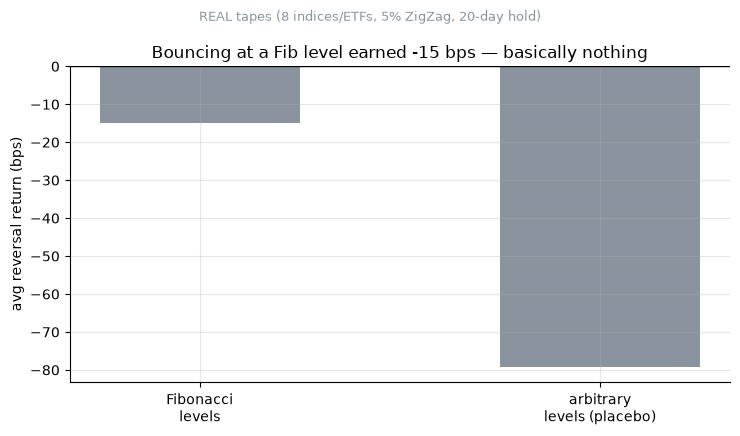

Fibonacci arm -15 bps (t -0.27)  |  placebo arm -79 bps


In [2]:
if HAVE_REAL:
    fa, pa = pooled_arms(TAPES)
    fib_bps, fib_t = fa.mean()*1e4, st.ttest_vs_zero(fa)
    plc_bps = pa.mean()*1e4
    banner = f'REAL tapes ({len(TAPES)} indices/ETFs, 5% ZigZag, 20-day hold)'
else:
    fib_bps, fib_t, plc_bps = -15.0, -0.27, -79.2
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['Fibonacci\nlevels', 'arbitrary\nlevels (placebo)'], [fib_bps, plc_bps],
       color=[GREY, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('avg reversal return (bps)')
ax.set_title(f'Bouncing at a Fib level earned {fib_bps:+.0f} bps — basically nothing')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'Fibonacci arm {fib_bps:+.0f} bps (t {fib_t:+.2f})  |  placebo arm {plc_bps:+.0f} bps')

There it is. Betting the bounce at a Fibonacci level earned **-15 bps** per trade (*t* -0.27) — indistinguishable from zero. And the *arbitrary* levels did about the same. The 'magic' 38.2% / 61.8% lines aren't special.

**Is Fibonacci at least *better* than a random level?** Look at the gap between the two arms across different chart settings (how sensitive the ZigZag is, how long you hold):

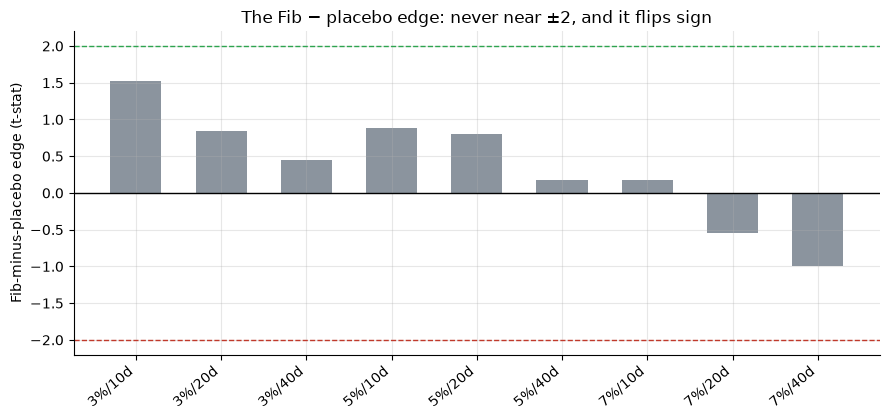

edge t-stats: [1.53, 0.84, 0.45, 0.89, 0.8, 0.18, 0.18, -0.55, -1.0]


In [3]:
grid = [(0.03, 10, 505, -0.68, 1.53), (0.03, 20, 505, -0.71, 0.84), (0.03, 40, 505, -1.01, 0.45), (0.05, 10, 225, -0.81, 0.89), (0.05, 20, 225, -0.27, 0.8), (0.05, 40, 225, 0.65, 0.18), (0.07, 10, 139, -0.53, 0.18), (0.07, 20, 139, -0.12, -0.55), (0.07, 40, 138, 0.47, -1.0)]
labs = [f'{int(p*100)}%/{h}d' for (p,h,_,_,_) in grid]
edge = [e for (_,_,_,_,e) in grid]
fig, ax = plt.subplots(figsize=(9, 4.3))
cols = [GREEN if abs(x)>=2 else GREY for x in edge]
ax.bar(range(len(edge)), edge, color=cols, width=.6)
ax.axhline(0, c='k', lw=1); ax.axhline(2, ls='--', c=GREEN, lw=1)
ax.axhline(-2, ls='--', c=RED, lw=1)
ax.set_xticks(range(len(edge))); ax.set_xticklabels(labs, rotation=40, ha='right')
ax.set_ylabel('Fib-minus-placebo edge (t-stat)')
ax.set_title('The Fib \u2212 placebo edge: never near \u00b12, and it flips sign')
plt.tight_layout(); plt.show()
print('edge t-stats:', edge)

The edge of Fibonacci *over* arbitrary levels wanders between about **+1.5 and −1.0** depending on the settings — never close to the ±2 you'd need to believe it, and it doesn't even keep the same sign. That's the fingerprint of **noise**, not a real effect.

## 5 · The verdict

- **Signal — None.** The bounce bet at a Fib level earns nothing (*t* -0.27) and isn't better than a random level.
- **Tradability — Mirage.** Flat-to-negative before costs; per-chart results are pure scatter.
- **Fib levels special? — Not supported.** Arbitrary fractions do just as well; a coin at the same swings matches the Fibonacci arm.

## 6 · Could you actually trade it?

No. Even ignoring the missing edge, the per-tape results swing from a big *loss* on small-caps to a big *gain* on the Nasdaq-100 with no rhyme or reason — that's what you get averaging noise. And you'd pay a spread every time you place the trade, turning a flat bet into a small loss.

## 7 · Going further 🚪

- **The wave version.** [445 Elliott Wave](../../445-elliott-wave/) tests the full 'buy wave 3' count that Fibonacci ratios are part of — also a null.
- **Other 'levels'.** [93 Round Numbers](../../93-round-numbers/) and the pivot-point studies ([440](../../440-pivot-points/)) ask the same 'is this line special?' question.

*Think Fibonacci works and we missed it? Fork this, add intraday or single-name tapes, and show the Fib arm beating the arbitrary-fraction placebo at t \u2265 2.*